# Power Analysis

In this notebook, we see how to do effect size, power and sample size calculations for the t-tests, based on [statsmodels' Power and Sample Size Calculations](https://www.statsmodels.org/stable/stats.html#power-and-sample-size-calculations); also known as **Power Analysis**.

We lean how to:

1. measure the **effect size** in observed data,
2. compute the **power** for a certain test, sample size and effect size
3. compute the **minimum sample size** required to reach a power of 80% given this test and sample size

## Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

# statsmodels power analysis classes
# docs: https://www.statsmodels.org/stable/stats.html#power-and-sample-size-calculations
from statsmodels.stats.power import (
    TTestPower,        # one-sample and paired t-tests
    TTestIndPower,     # two independent samples t-test
)

sns.set_theme(style="white")


## The Four-Way Relationship

These four are linked by a single equation. **Fix any three, and the fourth is determined.** Power analysis is just choosing which one to solve for:

| Question | Solve for |
| --- | --- |
| "How many subjects do I need?" | $n$ |
| "How small a difference could I have caught?" | effect size |
| "What was my chance of finding it?" | power |
| "What false-positive rate did I take?" | $\alpha$ |

In `statsmodels`, every power class exposes the same method — `solve_power(...)` — and you simply pass `None` for the unknown.


## Effect Size: The "Loudness" of the Signal

Effect size is **standardized** — the units cancel out, so it is comparable across studies and disciplines.

- A difference of "10 SAR" tells you nothing on its own.
- *Dividing by the standard deviation* is what turns a raw difference into a meaningful, comparable signal.

**Cohen's $d$** for comparing two means (don't worry about the math):

$$ d = \frac{\bar{x}_1 - \bar{x}_2}{s_{\text{pooled}}} $$

$$ s_{\text{pooled}} = \sqrt{\tfrac{(n_1-1)s_1^2 + (n_2-1)s_2^2}{n_1 + n_2 - 2}} $$

We have encoded this math into `utils` as well as the heuristic for qualifying the magnitude of the effect (`"small", "medium", "large"`) so we'll just import it (feel free to look at the code):

In [2]:
from utils import calculate_effect_size, qualify_effect_size

## statsmodels Power Mapping

Pick the class that matches your test, then call `solve_power(...)`.

| Test | Class | Docs |
| --- | --- | --- |
| One sample or paired $t$-test | `TTestPower` | [link](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestPower.html) |
| Independent two-sample $t$-test | `TTestIndPower` | [link](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestIndPower.html) |

---

# $H_1$: NBA players are taller than the general population

*Test type:* **one-sample** $t$-test — compare a sample (NBA players) to a known population mean ($\mu_{\text{adult male}} \approx 1.72$ meters, from the SOCR Height-Weight dataset).

The interesting power question is *not* "is it significant?" (it is, dramatically). It is:

- given an effect this large, *how few NBA players* would we have needed to sample?


In [3]:
DATA_DIR = Path("../data")

# NBA player heights — https://github.com/simonwarchol/NBA-Height-Weight
nba = pd.read_csv(DATA_DIR / "nba_heights.csv")
nba.describe()

,h_meters,h_in
count,435.000000,435.000000
mean,2.012483,79.209195
std,0.090078,3.573444
min,1.750000,69.000000
25%,1.960000,77.000000
50%,2.030000,80.000000
75%,2.080000,82.000000
max,2.290000,90.000000


In [4]:
# Reference (population) parameters for adult males in inches, from the SOCR Height-Weight dataset
# https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset
humans = pd.read_csv(DATA_DIR / "SOCR-HeightWeight_modified.csv").sample(len(nba))
humans.describe()

,Index,Height(m),Weight(kg),BMI
count,435.000000,435.000000,435.000000,435.000000
mean,12457.425287,1.727144,57.896538,19.401721
std,7269.255519,0.050542,5.295304,1.505172
min,42.000000,1.590195,42.539137,14.686357
25%,6196.500000,1.692862,54.168750,18.436753
50%,12386.000000,1.727949,57.709512,19.356263
75%,18899.500000,1.762370,61.471264,20.311066
max,24995.000000,1.883866,72.526004,23.743827


In [5]:
# Select and rename the height columns to 'height_m', and add a 'group' indicator
nba_height = nba[['h_meters']].rename(columns={'h_meters': 'height_m'})
nba_height['group'] = 'NBA'

humans_height = humans[['Height(m)']].rename(columns={'Height(m)': 'height_m'})
humans_height['group'] = 'Human'

# Concatenate both into one dataframe
df_full = pd.concat([nba_height, humans_height], ignore_index=True)

In [6]:
df_full

,height_m,group
0,1.960000,NBA
1,1.930000,NBA
2,1.960000,NBA
3,1.960000,NBA
4,2.130000,NBA
...,...,...
865,1.740781,Human
866,1.754256,Human
867,1.762673,Human
868,1.659990,Human


For the sake of getting a sense of the data, we'll plot both distributions:

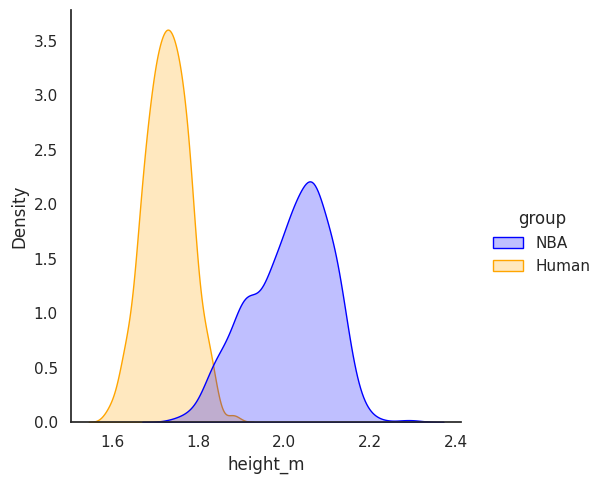

In [7]:
sns.displot(
    data=df_full,
    kind='kde',
    fill=True,
    x="height_m",
    hue="group",
    palette=["blue", "orange"],
    alpha=0.25,
)

Let's calculate the population mean and standard deviation:

In [8]:
# humans = pd.read_csv(DATA_DIR / "SOCR-HeightWeight_modified.csv")
# pop_mean = humans['Height(m)'].mean()
# pop_std  = humans['Height(m)'].std()
# del humans

# print(f"Population mean: {pop_mean:.4f}m")
# print(f"Population std: {pop_std:.4f}m")

In [9]:
pop_mean = 1.7270
pop_std  = 0.0483

In [ ]:
nba = df_full.loc[df_full["group"] == "NBA", "height_m"]
pop = df_full.loc[df_full["group"] == "Human", "height_m"]

## Step 1. Calculate Effect Size

In [42]:
n_observed = len(nba)
effect_size = calculate_effect_size(nba, popmean=pop_mean)

print(f"n observed = {n_observed}")
print(f"mean nba height: {nba.mean():.2f}m")
print(f"mean human height: {pop_mean:.2f}m")
print(f"effect size = {effect_size:.2f}")
print(f"qualified effect size = {qualify_effect_size(effect_size, n_groups=1)}")

n observed = 435
mean nba height: 2.01m
mean human height: 1.73m
effect size = 3.17
qualified effect size = large


## Step 2. Solve for Power

In [12]:
# https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestPower.solve_power.html
analysis = TTestPower()

power = analysis.solve_power(
    effect_size=effect_size,         # the signal we observed
    nobs=n_observed,              # the sample we actually collected
    alpha=0.05,                   # conventional false-positive rate
    power=None,                   # <-- the unknown we are solving for
    alternative="larger",         # one-tailed: NBA > population
)

print(f"observed power = {power * 100:.2f}%  (essentially certain to detect)")

observed power = 100.00%  (essentially certain to detect)


## Step 3. Minimum Sample Size for 80% power?

A power of 80% is the conventional planning target. Solve for `nobs` instead:

In [13]:
n_needed = analysis.solve_power(
    effect_size=effect_size,
    nobs=None,                    # <-- now n is the unknown
    alpha=0.05,
    power=0.80,
    alternative="larger",
)

print(f"n needed for 80% power = {np.ceil(n_needed):.0f} NBA players")
print(f"(we used {n_observed}, so we had way more than we needed)")


n needed for 80% power = 3 NBA players
(we used 435, so we had way more than we needed)


**Take-away** — with an effect this loud, even a handful of players would have settled the question. The 435-row dataset was wildly overpowered. This is the kind of insight a plain p-value cannot give you.


---

# $H_2$: Spinach increases grip strength (paired)

*Test type:* **paired** $t$-test — same subjects measured before and after, so each "before" is naturally linked to its "after".

For a paired test we work on the **differences** ($\Delta_i = \text{after}_i - \text{before}_i$):

$$ d = \frac{\bar{\Delta}}{s_\Delta} $$


In [ ]:
grip = pd.DataFrame({
    "subject": list(range(1, 20+1)),
    "before":  [50, 52, 55, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 70, 72],
    "after":   [60, 68, 50, 55, 59, 61, 62, 63, 64, 65, 66, 67, 68, 70, 72, 73, 75, 76, 77, 78],
})

,subject,before,after,difference
count,20.00000,20.00000,20.000000,20.000000
mean,10.50000,60.60000,66.450000,5.850000
std,5.91608,6.26099,7.500702,3.787445
min,1.00000,50.00000,50.000000,-5.000000
25%,5.75000,55.75000,61.750000,5.000000
50%,10.50000,60.50000,66.500000,5.000000
75%,15.25000,65.25000,72.250000,7.000000
max,20.00000,72.00000,78.000000,16.000000


To draw a relational plot for each subject, we need to `melt` the dataframe to have a column indicated who took the treatment and who did not:

In [ ]:
df_grip = grip.melt(id_vars=['subject'], value_vars=['before', 'after'])
df_grip.sample(5)

,subject,variable,value
31,12,after,67
29,10,after,65
36,17,after,75
10,11,before,61
2,3,before,55


Now we can look at each subject's performance, using the `relplot(kind="line")` like so:

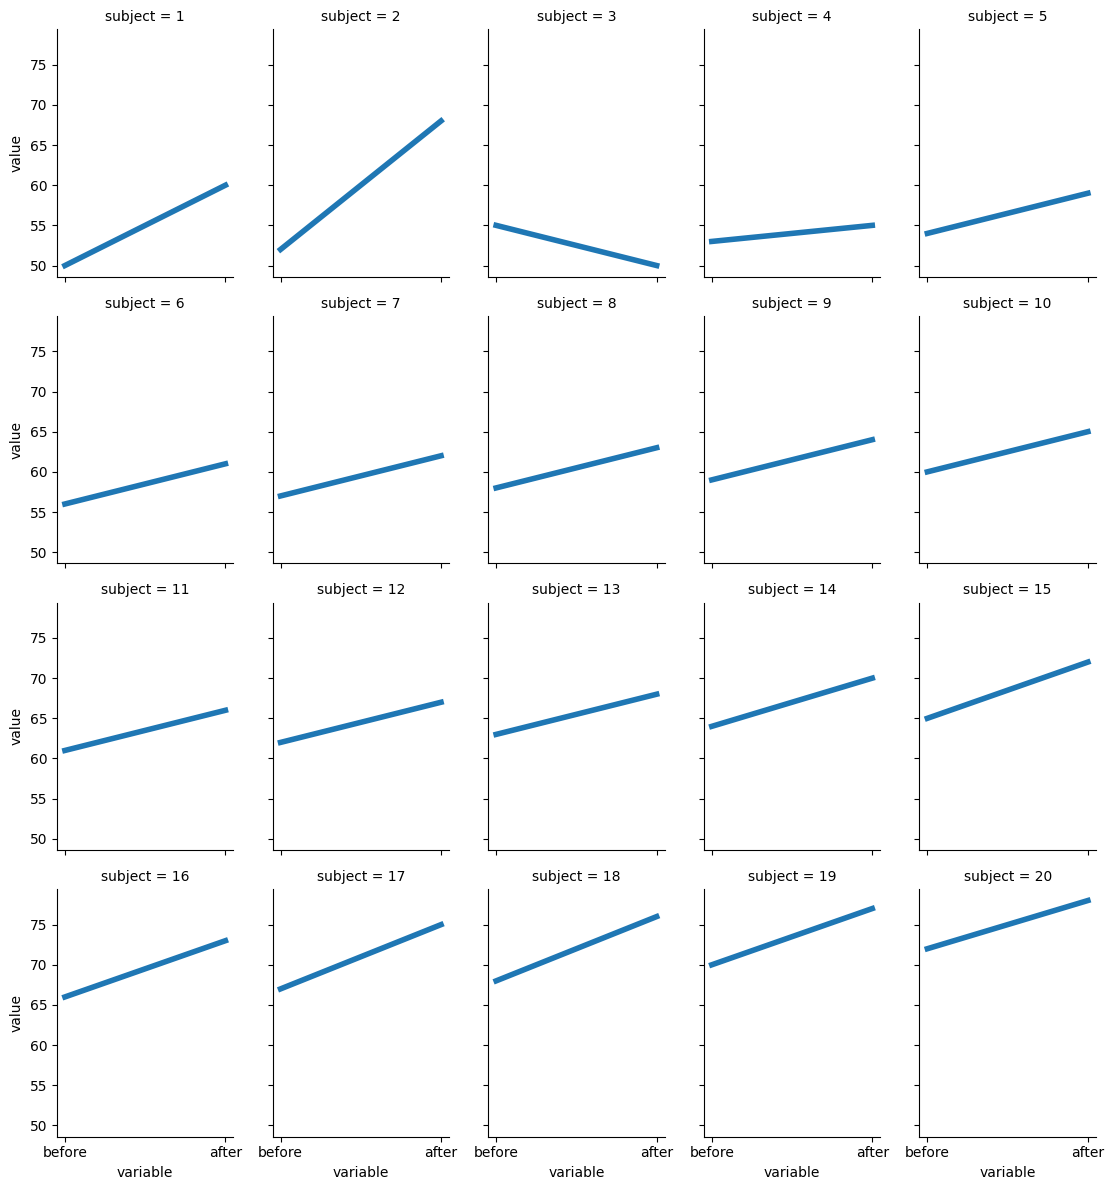

In [ ]:
sns.relplot(
    df_grip,
    kind='line',
    x='variable',
    y='value',
    col='subject', col_wrap=5,
    height=3, aspect=.75, linewidth=4,
)

Since we are looking for **change** we need to measure the `difference`:

In [ ]:
grip["difference"] = grip["after"] - grip["before"]
grip.describe()

Using a `catplot(kind="point")` plot, one can visualize the **mean and standard deviation** of the `diffference` for the sample, not individuals:

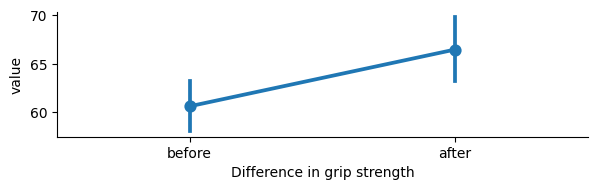

In [ ]:
g = sns.catplot(
    df_grip,
    x='variable',
    y='value',
    kind='point',
    height=2, aspect=3
)
g.set_xlabels("Difference in grip strength");

## Step 1. Calculate Effect Size

In [19]:
n_observed = len(grip)
effect_size = calculate_effect_size(
    grip["difference"],
    popmean=0    # Null hypothesis: no effect
)
print(f"effect size = {effect_size:.2f}")
print(f"n observed = {n_observed}")
print(f"qualified effect size = {qualify_effect_size(effect_size, n_groups=1)}")

effect size = 1.54
n observed = 20
qualified effect size = large


## Step 2. Solve for Power

In [20]:
analysis = TTestPower()       # paired uses the same class as one-sample

power = analysis.solve_power(
    effect_size=effect_size,
    nobs=n_observed,
    alpha=0.05,
    power=None,
    alternative="larger",     # H_a: spinach increases strength
)

print(f"observed power = {power * 100:.2f}%   (with n = {n_observed})")

observed power = 100.00%   (with n = 20)


## Step 3. Minimum Sample Size for 80% power?

A power of 80% is the conventional planning target. Solve for `nobs` instead:

In [21]:
n_needed = analysis.solve_power(
    effect_size=effect_size,
    nobs=None,
    alpha=0.05,
    power=0.80,
    alternative="larger",
)

print(f"n needed for 80% power = {np.ceil(n_needed):.0f}")

n needed for 80% power = 5


# $H_3$: Male penguins weigh more than female penguins

*Test type:* **two independent samples** $t$-test — males vs. females are different penguins, so the groups are independent.

In [24]:
penguins = sns.load_dataset("penguins").dropna()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


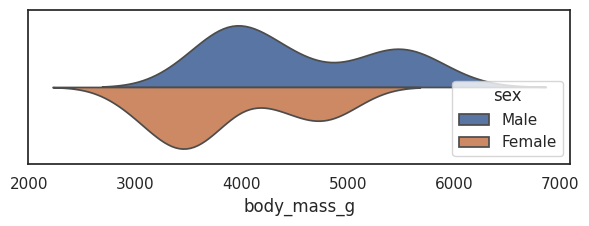

In [44]:
fig, ax = plt.subplots(figsize=(7, 2))

sns.violinplot(
    data=penguins,
    x="body_mass_g",
    hue="sex",
    split=True,
    inner=None,
    ax=ax,
)
plt.show()


In [26]:
males   = penguins.loc[penguins["sex"] == "Male",   "body_mass_g"]
females = penguins.loc[penguins["sex"] == "Female", "body_mass_g"]

## Step 1. Calculate Effect Size

In [40]:
n1, n2 = len(males), len(females)
m1, m2 = males.mean(), females.mean()
effect_size = calculate_effect_size(males, females)

print(f"n observed = {n1} males and {n2} females")
print(f"mean mass: {m1:.2f}g males and {m2:.2f}g females")
print(f"effect size = {effect_size:.2f}")
print(f"qualified effect size = {qualify_effect_size(effect_size, n_groups=2)}")

n observed = 168 males and 165 females
mean mass: 4545.68g males and 3862.27g females
effect size = 0.94
qualified effect size = large


## Step 2. Solve for Power

In [29]:
# https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestIndPower.solve_power.html
analysis = TTestIndPower()

power = analysis.solve_power(
    effect_size=effect_size,
    nobs1=n1,                 # group-1 sample size (males)
    ratio=n2 / n1,            # how many group-2 observations per group-1 observation
    alpha=0.05,
    power=None,               # <-- solving for power
    alternative="larger",     # H_a: males heavier
)

print(f"observed power = {power * 100:.2f}%")


observed power = 100.00%


## Step 3. Minimum Sample Size for 80% power?

A power of 80% is the conventional planning target. Solve for `nobs` instead:

In [30]:
n_per_group = analysis.solve_power(
    effect_size=effect_size,
    nobs1=None,               # <-- solving for nobs1 now
    ratio=1.0,                # equal-sized groups
    alpha=0.05,
    power=0.80,
    alternative="larger",
)

print(f"n per group needed for 80% power = {np.ceil(n_per_group):.0f}")
print(f"(we had {n1} males / {n2} females, again much more than required)")

n per group needed for 80% power = 15
(we had 168 males / 165 females, again much more than required)


# $H_4$: Adile Penguins Weigh more than Chinstrap

*Test type:* **two independent samples** $t$-test.

This example is more interesting because the signal is *quiet* — and that is exactly when power analysis earns its keep.

<Figure size 800x400 with 0 Axes>

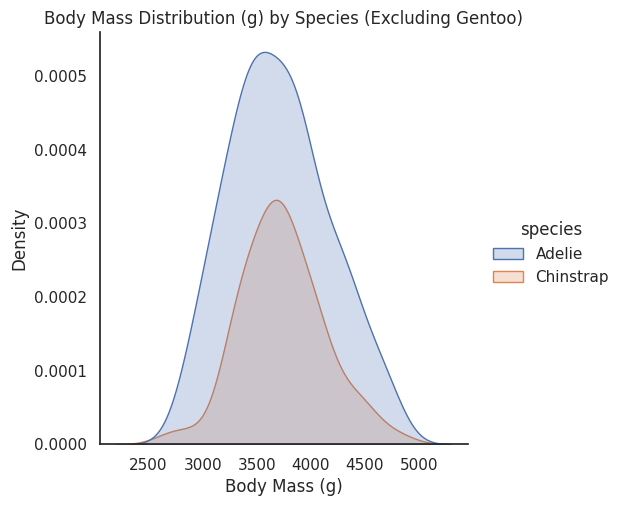

In [85]:
penguins = sns.load_dataset("penguins").dropna()

# Drop Gentoo species completely
penguins_no_gentoo = penguins[penguins["species"] != "Gentoo"]

# Plot histograms of body_mass_g for remaining species
plt.figure(figsize=(8, 4))
sns.displot(
    data=penguins_no_gentoo,
    kind='kde',
    fill=True,
    x="body_mass_g",
    hue="species",
)
plt.title("Body Mass Distribution (g) by Species (Excluding Gentoo)")
plt.xlabel("Body Mass (g)")
plt.ylabel("Density")
plt.show()


In [86]:
adelie     = penguins_no_gentoo.loc[penguins_no_gentoo["species"] == "Adelie", "body_mass_g"]
chinstrap = penguins_no_gentoo.loc[penguins_no_gentoo["species"] == "Chinstrap", "body_mass_g"]

## Step 1. Calculate Effect Size

In [88]:
n1, n2 = len(adelie), len(chinstrap)
m1, m2 = adelie.mean(), chinstrap.mean()
effect_size = calculate_effect_size(adelie, chinstrap)

print(f"n observed = {n1} adelie and {n2} chinstrap")
print(f"mean mass: {m1:.0f}g adelie and {m2:.0f}g chinstrap")
print(f"effect size = {effect_size:.2f}")
print(f"qualified effect size = {qualify_effect_size(effect_size, n_groups=2)}")

n observed = 146 adelie and 68 chinstrap
mean mass: 3706g adelie and 3733g chinstrap
effect size = -0.06
qualified effect size = small


## Step 2. Solve for Power

In [89]:
analysis = TTestIndPower()

power = analysis.solve_power(
    effect_size=abs(effect_size),
    nobs1=n1,
    ratio=n2 / n1,
    alpha=0.05,
    power=None,
    alternative="two-sided",  # we did not pre-commit to a direction
)

print(f"observed power = {power * 100:.2f}%")

observed power = 7.03%


## Step 3. Minimum Sample Size for 80% power?

A power of 80% is the conventional planning target. Solve for `nobs` instead:

In [90]:
n_per_group = analysis.solve_power(
    effect_size=effect_size,
    nobs1=None,
    ratio=1.0,
    alpha=0.05,
    power=0.80,
    alternative="two-sided",
)

print(f"n per group needed for 80% power = {np.ceil(n_per_group):.0f}")

n per group needed for 80% power = 4128


**Take-away** — this is the lesson from the basement analogy in reverse: the basement is *messy* (high variance) and the tool is *tiny* (small effect), so a quick search (small $n$) tells us essentially nothing. A "no significant difference" headline from a study like this should be read as *"we did not look hard enough"*, not *"there is nothing there"*.
